In [1]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
    RestOf
)
from imagematerials.preprocessing import get_preprocessing_data
import numpy as np



In [2]:
#load historic data
from imagematerials.rest_of.resource_model import ResourceModel

steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                        image_mat_available = True, start_year = 1971,
                        scenario="SSP2_M_CP",
                        convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                        trade_data=True, path_input_data="../data/raw/rest-of", 
                        path_input_data_image = Path("../data/raw/image"))

aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                        image_mat_available = True, start_year = 1998, 
                        scenario="SSP2_M_CP", end_year = 2024, path_input_data="../data/raw/rest-of", 
                        path_input_data_image = Path("../data/raw/image")
                        )


In [3]:
from imagematerials.rest_of import rest_of_preprocessing

In [4]:
image_scenario = "SSP2_M_CP"
climate_policy_scenario_dir = Path("..", "data", "raw", "image", image_scenario)

In [5]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1970, 2100, 1)


bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None) 
vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None)
rest_sector = rest_of_preprocessing(Path("..", "data", "raw"), 
                    image_scenario_directory = climate_policy_scenario_dir)

# TODO fix this for real in the future
prep_data = vhc_sector.prep_data

target_materials = [
"Aluminium", "Brick", "Cement", "Concrete", 
"Copper", "Glass", "Steel", "Wood"
]

vhc_sector = Sector('vehicles', prep_data)
rest_sector = Sector(name='rest_of', 
                    data = rest_sector,)

factory = ModelFactory(
[bld_sector, vhc_sector, rest_sector], complete_timeline
).add(GenericStocks, ["buildings", "vehicles"]
).add(GenericMaterials,  "vehicles"
).add(MaterialIntensities, "buildings",
).add(RestOf, "rest_of", input_sources={
    "gompertz_coefs": "rest_of",
    "gdp_per_capita": "rest_of",
    "population": "rest_of",
}
)
model = factory.finish()

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model.simulate(simulation_timeline)



c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1566: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


In [6]:
from imagematerials.rest_of.const import IAI_TO_IMAGE_CLASSES


In [7]:
IAI_TO_IMAGE_CLASSES.get('Western & Central Europe')

['class_ 11', 'class_ 12', 'class_ 13']

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


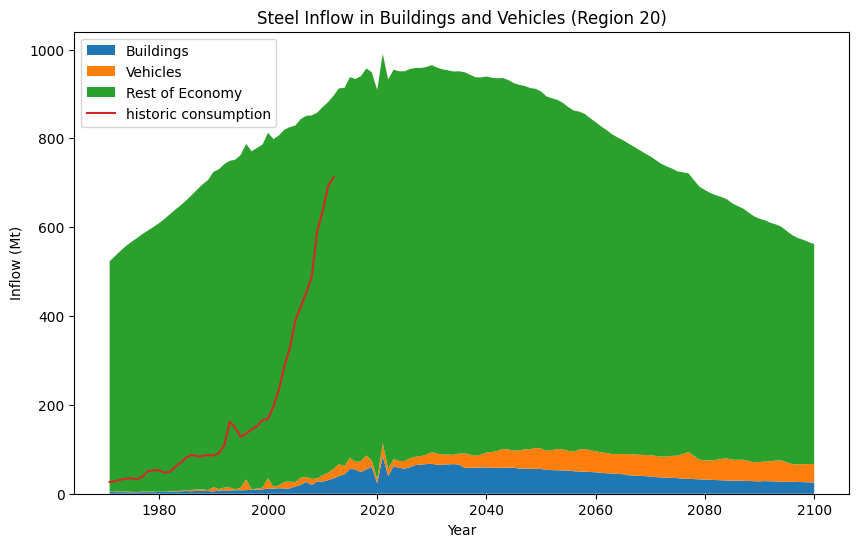

In [8]:
# stack plot of material inflow in buildings and vehicles
material_sel = "Steel"
all_regions = list(range(1, 27))
region_sel = "20"
import matplotlib.pyplot as plt

inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel, Region = region_sel).pint.to("Mt").sum(["Type"]).loc[1971:]
inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = material_sel, Region = region_sel).pint.to("Mt").sum(["Type"]).loc[1971:]
inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel, Region = region_sel).pint.to("Mt").loc[1971:].rename({'Time': 'time'})
years = inflow_buildings.coords['time'].values

historic_consumption_data = steel.historic_consumption_data.loc[:, f"class_ {region_sel}"] / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(years, inflow_buildings, inflow_vehicles, inflow_rest, labels=['Buildings', 'Vehicles', 'Rest of Economy'])
historic_consumption_data.plot(label = "historic consumption")


ax.set_title(f'{material_sel} Inflow in Buildings and Vehicles (Region {region_sel})')
ax.set_xlabel('Year')
ax.set_ylabel('Inflow (Mt)')
ax.legend(loc='upper left')
plt.show()


c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


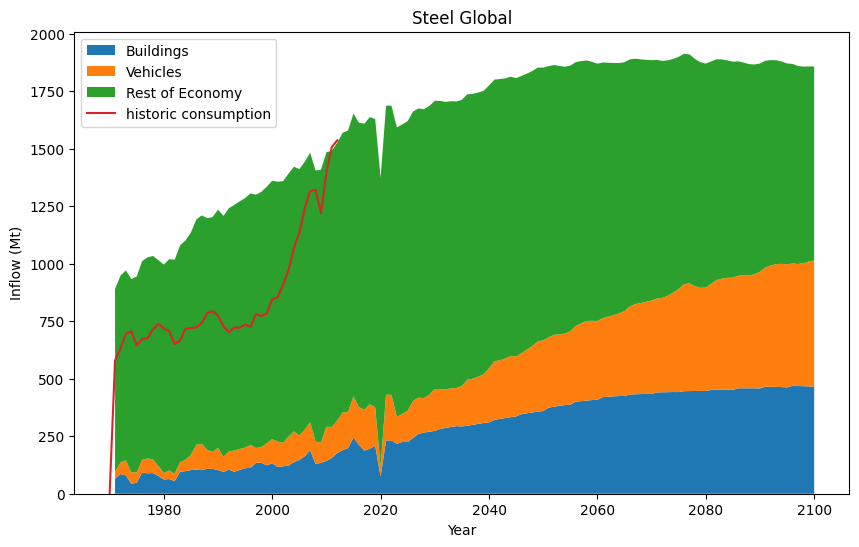

In [9]:
# stack plot of material inflow in buildings and vehicles
material_sel = "Steel"
all_regions = list(range(1, 27))

import matplotlib.pyplot as plt

inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel).pint.to("Mt").loc[1971:].sum(["Region"]).rename({'Time': 'time'})
years = inflow_buildings.coords['time'].values

historic_consumption_data = steel.historic_consumption_data.sum(axis = 1) / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(years, inflow_buildings, inflow_vehicles, inflow_rest, labels=['Buildings', 'Vehicles', 'Rest of Economy'])
historic_consumption_data.plot(label = "historic consumption")


ax.set_title(f'{material_sel} Global')
ax.set_xlabel('Year')
ax.set_ylabel('Inflow (Mt)')
ax.legend(loc='upper left')
plt.show()

In [10]:
steel.historic_consumption_data

,class_ 1,class_ 2,class_ 3,class_ 4,class_ 5,class_ 6,class_ 7,class_ 8,class_ 9,class_ 10,...,class_ 17,class_ 18,class_ 19,class_ 20,class_ 21,class_ 22,class_ 23,class_ 24,class_ 25,class_ 26
1970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1971,11753000.0,127663000.0,4051000.0,441000.0,7386000.0,8192000.0,2470000.0,540000.0,0.0,5532000.0,...,4334000.0,7710000.0,3847000.0,26517000.0,3167000.0,612000.0,57699000.0,8190000.0,662000.0,1909000.0
1972,12842000.0,138410000.0,4684000.0,557000.0,7662000.0,8651000.0,2896000.0,571000.0,0.0,4881000.0,...,4868000.0,9227000.0,4031000.0,28022000.0,4044000.0,1030000.0,68888000.0,8721000.0,461000.0,2327000.0
1973,14153000.0,149595000.0,5174000.0,728000.0,9513000.0,9260000.0,3199000.0,710000.0,0.0,5636000.0,...,6759000.0,8221000.0,5906000.0,31665000.0,4722000.0,1442000.0,87181000.0,8152000.0,554000.0,3034000.0
1974,15458000.0,144120000.0,6112000.0,925000.0,12799000.0,11024000.0,4221000.0,884000.0,0.0,6494000.0,...,9101000.0,8551000.0,7664000.0,33796000.0,5197000.0,1280000.0,75753000.0,8843000.0,536000.0,3254000.0
1975,13178000.0,116821000.0,6211000.0,1086000.0,11241000.0,10182000.0,4579000.0,1380000.0,0.0,7506000.0,...,11525000.0,8500000.0,6498000.0,34891000.0,4559000.0,1446000.0,64736000.0,7328000.0,630000.0,2692000.0
1976,12570000.0,129953000.0,5962000.0,1008000.0,10715000.0,9474000.0,4326000.0,1327000.0,0.0,6066000.0,...,12445000.0,8202000.0,8445000.0,32159000.0,4953000.0,1382000.0,60176000.0,7530000.0,599000.0,2775000.0
1977,12828000.0,133923000.0,6487000.0,1000000.0,11976000.0,11054000.0,4800000.0,1799000.0,0.0,4871000.0,...,11388000.0,10185000.0,9162000.0,38497000.0,5176000.0,1744000.0,58243000.0,6097000.0,752000.0,3701000.0
1978,13524000.0,146445000.0,8060000.0,1000000.0,11932000.0,10553000.0,5086000.0,1380000.0,0.0,5111000.0,...,13230000.0,10060000.0,11688000.0,50741000.0,5617000.0,1964000.0,61507000.0,6075000.0,700000.0,3636000.0
1979,15525000.0,140906000.0,8840000.0,1000000.0,12760000.0,11003000.0,5621000.0,1025000.0,0.0,6300000.0,...,12865000.0,12050000.0,10347000.0,52797000.0,6260000.0,2005000.0,72329000.0,7645000.0,880000.0,3307000.0


In [11]:
inflow_buildings

Magnitude,[65.98809340953851 85.48521824792161 79.695062273525 43.69377052198608 47.65695142870429 92.4162573630646 88.6503604025336 89.73688658487171 76.99128799766133 61.93120983444105 63.82307468767 54.653862574663975 95.41991012361743 98.20079623944497 102.92480980922832 104.2926932016201 102.46709923512503 108.82950825417288 108.43334645382836 102.64740945605718 95.01849928702835 104.60869100892658 95.07921166982054 103.77823360502359 111.17015703093533 112.14549494384609 134.6768571909188 134.51144908083936 123.35912970148175 132.48101013607305 116.44228116779435 119.13647804470995 122.4655794331712 137.4032234228457 146.91936334247012 162.4533202881633 188.69372357933432 129.81794141727337 134.06073753576374 142.6845729102596 155.95078571914954 176.50511012096928 189.67763178101737 198.97486572769668 244.80934942644814 212.5968722543497 187.39883597389075 195.72314637495464 208.8070224940104 74.54259716914432 230.25539947160337 231.81337193122425 217.2292041920482 224.9138728413784 224.81840153690325 243.24626585362492 260.4078536124019 265.5920938853285 269.8714978746766 272.9679555332067 281.8556943939289 286.03344125498495 290.11961923171395 294.09033038897644 292.64764029127275 295.62332609288086 299.4330404608985 303.7534056935024 307.48463338255476 310.44184052625593 321.1234023753364 325.072812666138 329.0438676876138 332.97975737212903 335.87795601663584 346.09181494168206 349.87088404015833 353.50618876191066 356.89732113260993 359.4948870594744 374.25965103666346 378.3820577947064 382.3829394986491 385.5256835289315 387.516374943885 400.0463375675688 402.5938376447265 404.99475051740205 407.2401350652457 408.36144532125115 420.14525699018185 421.8339391020796 423.37078081018564 424.77604802404767 425.084209087679 431.4118792984517 432.4087236013717 433.3096865273669 434.11397924401456 434.0255399724862 440.44665379365927 441.11298039885446 441.68888434356825 442.1928569971127 441.8493445726498 445.99750584679975 446.3891237135043 446.73463717311677 447.03239749058514 446.55015538441995 451.5760048762845 451.8303554309507 452.02532737393017 452.1923705468862 451.59461754220087 458.3904179830422 458.4771639995963 458.54427562802726 458.57647744090104 457.8817855693376 465.6029869846227 465.25873236788175 464.4856729651154 463.67448812425 462.2901064498327 469.18846249385774 468.40064913634103 467.5722749355485 466.6867775573333 465.12513347447816]
Units,megametric_ton


In [12]:
# sum inflow materials for steel, sum also per types keep regions and year

materials_dict_metal = {
    'Steel' : 'Steel',
    'Aluminium' : 'Aluminium',
    'Copper' : 'Cu',
}

materials_dict_nmm = {
    'Cement' : 'Cement',
    'Sand' : 'Sand'
}

# Conversion factors
# always taking the lower range numbers to be cautios

# https://civiltoday.com/civil-engineering-materials/cement/10-cement-ingredients-with-functions
# Cement: Lime 60-75%, Silica 17-25%, other aggregates
# https://concretesupplyco.com/concrete-basics/
# Concrete:  10% cement, 20% air and water, 30% sand, and 40% gravel --> 30% + 40% = 70%
# https://samsa.org.uk/key_uses/glass.php, https://www.carmeuse.com/na-en/references/case-studies-success-stories/limestone-glassmaking-what-you-need-know
# Sand (silica) in glass: 70%, lime: 15%

cement_in_concrete = 0.1
sand_in_cement_conversion = 0.17 #(silica)
sand_gravel_in_concrete_conversion = 0.7
sand_in_glass_conversion = 0.7

only_buildings = ['Cement', 'Concrete']
only_vehicles = ['Glass']
not_in_any = ['Sand']

def sum_inflows_for_output(materials_dict, resource_group):
    for key, value in materials_dict.items():
        print(key)
        if key not in only_buildings and key not in only_vehicles and not key in not_in_any:
            inflow_buildings = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material=key).loc[1961:]
            inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sum(['Type']).sel(material=value).loc[1961:]
            total_material = inflow_buildings + inflow_vehicles
        if key == 'Cement':
            # add concrete to cement
            inflow_buildings_cement = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material=key).loc[1961:]
            inflow_buildings_concrete = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * cement_in_concrete
            total_material = inflow_buildings_cement + inflow_buildings_concrete
        if key == 'Sand':
            inflow_buildings_cement_sand = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Cement').loc[1961:]*sand_in_cement_conversion
            inflow_buildings_concrete_sand_via_cement = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * cement_in_concrete * sand_in_cement_conversion
            inflow_buildings_sand_in_concrete = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * sand_gravel_in_concrete_conversion
            inflow_vehicles_sand = model.vehicles.get('inflow_materials').to_array().sum(['Type']).sel(material='Glass').loc[1961:] * sand_in_glass_conversion
            total_material = inflow_buildings_cement_sand + inflow_buildings_concrete_sand_via_cement + inflow_buildings_sand_in_concrete + inflow_vehicles_sand

        # from total_material create a csv that has the years as rows and regions as columns, mae sure that region names are no just '1' but 'class_ 1'
        # also drop material dimension
        if key not in ['Copper', 'Cement', 'Sand']:
            total_material = total_material.drop_vars('material')
        # change the region coordinate so that it is class_ 1 instead of 1 , ...
        # Get the current region values
        regions = total_material.coords['Region'].values

        # Create new region names
        new_regions = [f'class_ {r}' for r in regions]

        # Assign the new region names to the coordinate
        total_material = total_material.assign_coords(Region=new_regions)
        # to t
        total_material = total_material.pint.to('t')
        # save as pandas to save as csv
        total_material = total_material.rename("total_material")
        # write key with a small letter
        key = key.lower()
        # to pandas
        total_material = total_material.to_dataframe().unstack()
        # drop unessecary column level index
        total_material.columns = total_material.columns.droplevel(0)
        # save as csv
        if key == 'sand':
            key = 'sand_gravel_crushed_rock'
            total_material = total_material.loc[1971:]
        else: 
            pass
        total_material.to_csv(f'../data/raw/rest-of/{resource_group}/image_materials_{key}.csv')
        print('done', key)
    return total_material


# total_material_metals = sum_inflows_for_output(materials_dict_metal, 'metals')
# total_material_nmm = sum_inflows_for_output(materials_dict_nmm, 'nmm')

